In [29]:
from pathlib import Path
import pandas as pd

path = "C:\\Users\\andre\\Documents\\Microlab\\Falaphel\\TOT-AFE\\BoardDAQ\\falaphel3-daq\\script_analisi\\DAC-data-analyzer\\combined_data.csv"

if not Path(path).exists():
    raise FileNotFoundError(f"File non trovato: {Path(path).resolve()}")

df = pd.read_csv(path, encoding="utf-8", engine="python")
df.head()

,row,col,voltage,tot_avg,tot_std,toa_avg,toa_std,efficiency_tot,efficiency_toa,tup,tdac_code
0,0,0,87,5.000,0.000,15.516,0.570,1.0,1.0,0,0
1,0,0,84,4.903,0.301,15.871,0.499,1.0,1.0,0,0
2,0,0,81,4.484,0.508,16.226,0.617,1.0,1.0,0,0
3,0,0,78,4.194,0.402,16.484,0.626,1.0,1.0,0,0
4,0,0,75,3.968,0.315,17.323,0.702,1.0,1.0,0,0


Numero di pixel unici: 256
  Pixel (row=0, col=0): Fit results t_up=1: {0: array([46.69172414,  1.07934912]), 8: array([50.97113223,  0.71959303]), 16: array([57.3956935,  1.3285437]), 24: array([63.19833502,  1.59083755]), 31: array([67.95475573,  1.05542561])}
  Pixel (row=0, col=1): Fit results t_up=1: {0: array([62.39092798,  2.10202406]), 8: array([69.95486015,  2.1063917 ]), 16: array([77.39738464,  1.23631277]), 24: array([85.59834766,  2.41561214]), 31: array([92.49155479,  1.68555445])}
  Pixel (row=0, col=2): Fit results t_up=1: {0: array([50.46396726,  1.82478484]), 8: array([56.53160919,  2.21620525]), 16: array([62.39647701,  1.23457749]), 24: array([67.70743031,  0.63695418]), 31: array([72.86117355,  1.90827019])}
  Pixel (row=0, col=3): Fit results t_up=1: {0: array([60.81368922,  1.19785399]), 8: array([67.614813  ,  1.06663479]), 16: array([75.09953389,  1.38559064]), 24: array([84.39647702,  1.23457749]), 31: array([92.21955648,  1.73645752])}
  Pixel (row=0, col=4):

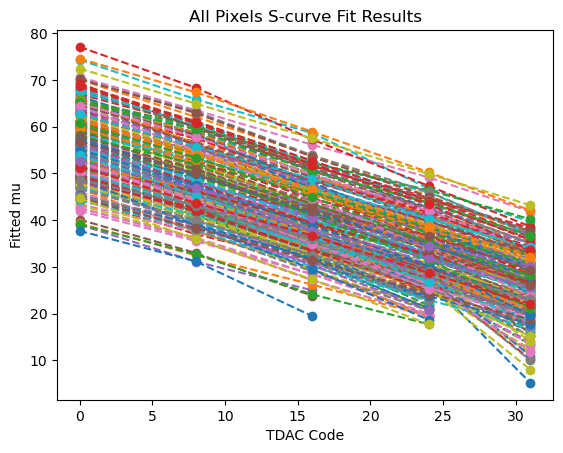

0


In [34]:
from scipy.optimize import curve_fit
from scipy.special import erf
import numpy as np
import matplotlib.pyplot as plt




# erf S-curve model
def myERF(x, mu, sigma):
    x = np.asarray(x)
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2.0))))


def fit_scurve(group):
    fit_results = {}
    for tdac_code, group in group:
        x_data = group['voltage'].values
        y_data = group['efficiency_toa'].values

        # initial guess for mu and sigma
        initial_guess = [np.median(x_data), max(1.0, (x_data.max() - x_data.min()) / 4.0)]

        try:
            popt, pcov = curve_fit(myERF, x_data, y_data,
                p0=initial_guess,
                bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                maxfev=5000,)
            fit_results[tdac_code] = popt  # store the fitted parameters
            

        except RuntimeError as e:
            print(f"    TDAC {tdac_code}: Fit failed: {e}")
 
    return fit_results


all_fit_data = []

# reaggruppa i dati per pixel, ovvero per row e col uguali
grouped = df.groupby(['row', 'col'])
print(f"Numero di pixel unici: {len(grouped)}")
negative_mean_count = 0

all_data = []
for (row, col), group in grouped:
    #print(f"Pixel (row={row}, col={col}): {len(group)} misure")

    # ciascun pixel deve essere diviso in base ai codici TDAC, considera anche che per ogni TDAC abbiamo dati distinti per t_up = 0 e t_up = 1
    tdac_groups_up1 = group[group['tup'] == 1].groupby('tdac_code')
    tdac_groups_up0 = group[group['tup'] == 0].groupby('tdac_code')

    fit_results_up1 = fit_scurve(tdac_groups_up1)
    fit_results_up0 = fit_scurve(tdac_groups_up0)
    print(f"  Pixel (row={row}, col={col}): Fit results t_up=1: {fit_results_up1}")

    all_data.append({
        'row': row,
        'col': col,
        'fit_results_up1': fit_results_up1,
        'fit_results_up0': fit_results_up0
    })


    # individua i pixel con media negativa
    mean_mu_up1 = np.mean([params[0] for params in fit_results_up1.values()])
    mean_mu_up0 = np.mean([params[0] for params in fit_results_up0.values()])
    
    
    # faccio il plot per il primo pixel come esempio in cui sulla x metto i TDAC e sulla y i mu ottenuti dal fit
    tdac_codes = sorted(fit_results_up1.keys())
    mu_values_up1 = [fit_results_up1[tdac][0] for tdac in tdac_codes]
    mu_values_up0 = [fit_results_up0[tdac][0] for tdac in tdac_codes]

    #plt.plot(tdac_codes, mu_values_up1, marker='o', label='t_up = 1')
    #plt.plot([x*-1 for x in tdac_codes], mu_values_up0, marker='o', label='t_up = 0')

    # plot solo dei valori positivi
    
    mu_values_up1_positive = [mu if mu > 0 else np.nan for mu in mu_values_up1]
    mu_values_up0_positive = [mu if mu > 0 else np.nan for mu in mu_values_up0]
    #plt.plot(tdac_codes, mu_values_up1_positive, marker='o', label='t_up = 1 (positive mu)', linestyle='--')
    plt.plot(tdac_codes, mu_values_up0_positive, marker='o', label='t_up = 0 (positive mu)', linestyle='--')
    
    #plt.plot([x*-1 for x in tdac_codes], mu_values_up0_positive, marker='o', label='t_up = 0 (positive mu)', linestyle='--')
    


plt.xlabel('TDAC Code')
plt.ylabel('Fitted mu')
plt.title(f'All Pixels S-curve Fit Results')
#plt.legend()
plt.show()
print(negative_mean_count)

# salva all_data come csv
output_rows = []
for pixel_data in all_data:
    row = pixel_data['row']
    col = pixel_data['col']
    for tdac_code, params in pixel_data['fit_results_up1'].items():
        mu, sigma = params
        output_rows.append({
            'row': row,
            'col': col,
            'tdac_code': tdac_code,
            'tup': 1,
            'mu': np.round(mu,2),
            'sigma': np.round(sigma,2)
        })
    for tdac_code, params in pixel_data['fit_results_up0'].items():
        mu, sigma = params
        output_rows.append({
            'row': row,
            'col': col,
            'tdac_code': tdac_code,
            'tup': 0,
            'mu': np.round(mu,2),
            'sigma': np.round(sigma,2)
        })


output_df = pd.DataFrame(output_rows)
output_df.to_csv("scurve_fit_results.csv", index=False)

Fit results: mu = 0.90 * TDAC + 53.85


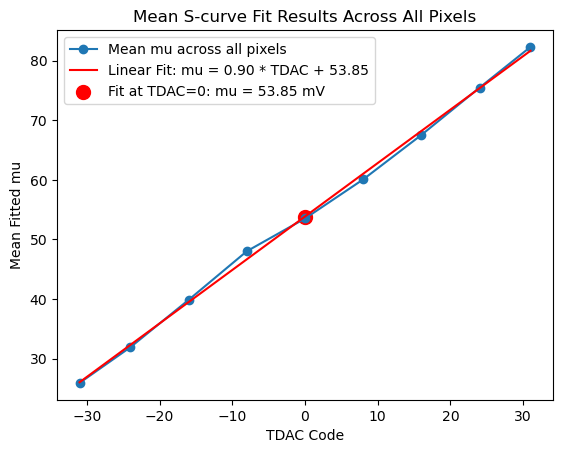

Range correttivo dei mu medi: 56.38 mV
Ogni step del TDAC corrisponde a un cambiamento di mu di circa: 0.89 mV


In [100]:
# apri il file appena salvato e dividi i dati in diversi dataframe raggruppando i tdac_code uguali
verify_df = pd.read_csv("scurve_fit_results.csv")
tdac_groups = verify_df.groupby(['tdac_code', "tup"])

data =  {}
for (tdac_code, tup), group in tdac_groups:
    # calcola la media scartando i dati negativi
    mu_values = group['mu'].values
    positive_mu_values = mu_values[mu_values > 0]
    mean_mu = np.mean(positive_mu_values)
    # se tup = 1, considera tdac_code positivo, altrimenti negativo
    if tup == 1:
        data[tdac_code] = np.round(mean_mu, 2)
        pass   
    else:
        data[-tdac_code] = np.round(mean_mu, 2)


#print(data)

# fai un plot di data
tdac_codes = sorted(data.keys())
mu_values = [data[tdac] for tdac in tdac_codes]
plt.plot(tdac_codes, mu_values, marker='o', label='Mean mu across all pixels')


# fai un fit ai minimi quadrati sui dati medi
def linear_func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(linear_func, tdac_codes, mu_values)
a, b = popt
# plot della retta di fit
x_fit = np.array(tdac_codes)
y_fit = linear_func(x_fit, a, b)
plt.plot(x_fit, y_fit, label=f'Linear Fit: mu = {a:.2f} * TDAC + {b:.2f}', color='red')


# sul punto di TDAC = 0 del fit, metti una x rossa
mu_at_tdac_0 = linear_func(0, a, b)
plt.scatter(0, mu_at_tdac_0, color='red', marker='o', s=100, label=f'Fit at TDAC=0: mu = {mu_at_tdac_0:.2f} mV')

print(f"Fit results: mu = {a:.2f} * TDAC + {b:.2f}")

plt.xlabel('TDAC Code')
plt.ylabel('Mean Fitted mu')
plt.title('Mean S-curve Fit Results Across All Pixels')
plt.legend()
plt.show()

# range correttivo è dato dal massimo - il minimo dei mu medi
mu_range = max(mu_values) - min(mu_values)
print(f"Range correttivo dei mu medi: {mu_range:.2f} mV")

#diviso i 6 bit di codici del tdac, significa che ogni bit del tdac corrisponde a un cambiamento di mu di:
tdac_step = mu_range / 63  
print(f"Ogni step del TDAC corrisponde a un cambiamento di mu di circa: {tdac_step:.2f} mV")


In [31]:
# apri il file scurve_fit_results.csv ed estrai solo i dati con tdac_code = 0 per tup = 1 e tup = 0
verify_df = pd.read_csv("scurve_fit_results.csv")
tdac_0_up0 = verify_df[(verify_df['tdac_code'] == 0) & (verify_df['tup'] == 0)]

# salva i dati in un nuovo file csv chiamato scurve_tdac0_fit_results.csv
tdac_0_up0.to_csv("scurve_tdac0_fit_results.csv", index=False)